# DRUG LABELS AND SIDE EFFECTS EDA ANALYSIS


This project performs exploratory data analysis on drug label information to understand patterns in side effects, severity, dosage, approval status, and drug classes, with the aim of identifying safety-related insights relevant to healthcare and pharmaceutical decision-making.

## Data Loading and Initial Exploration

### Importing libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix

### Loading the dataset

In [4]:
df=pd.read_csv(r"C:\Users\AnupaSusan\OneDrive\PROJECT\Data Science and analytics\realistic_drug_labels_side_effects.csv")
df.head()

,drug_name,manufacturer,approval_year,drug_class,indications,side_effects,dosage_mg,administration_route,contraindications,warnings,price_usd,batch_number,expiry_date,side_effect_severity,approval_status
0,Seroxetine50,AstraZeneca,1996,Antidepressant,Allergy relief,"Fatigue, Nausea",260,Rectal,Bleeding disorders,Avoid alcohol,192.43,MV388Pl,2026-11-29,Mild,Pending
1,Mecoparin93,AstraZeneca,2018,Vaccine,Allergy relief,Nausea,470,Inhalation,Allergic reaction,Take with food,397.82,UR279ZN,2027-07-14,Mild,Approved
2,Daxozole89,Merck & Co.,1997,Antipsychotic,Allergy relief,"Diarrhea, Blurred vision, Dizziness",330,Sublingual,High blood pressure,Take with food,131.69,we040kH,2028-06-02,Moderate,Pending
3,Viracillin84,Roche Holding AG,2004,Antifungal,Inflammation reduction,"Fatigue, Dry mouth",450,Oral,Kidney impairment,Do not operate machinery,372.82,hO060rh,2026-07-07,Mild,Rejected
4,Amoxstatin62,Pfizer Inc.,2003,Antidepressant,Psychosis control,"Insomnia, Dry mouth, Fatigue",430,Topical,Bleeding disorders,Do not operate machinery,281.48,Fa621Sw,2027-12-28,Moderate,Pending


###  Understanding the data

In [9]:
df.shape
df.columns
df.dtypes
df.info()
df.duplicated().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   drug_name             1436 non-null   object 
 1   manufacturer          1436 non-null   object 
 2   approval_year         1436 non-null   int64  
 3   drug_class            1436 non-null   object 
 4   indications           1436 non-null   object 
 5   side_effects          1436 non-null   object 
 6   dosage_mg             1436 non-null   int64  
 7   administration_route  1436 non-null   object 
 8   contraindications     1436 non-null   object 
 9   warnings              1436 non-null   object 
 10  price_usd             1436 non-null   float64
 11  batch_number          1436 non-null   object 
 12  expiry_date           1436 non-null   object 
 13  side_effect_severity  1436 non-null   object 
 14  approval_status       1436 non-null   object 
dtypes: float64(1), int64(

np.int64(0)

In [10]:
df.describe(include='all')

,drug_name,manufacturer,approval_year,drug_class,indications,side_effects,dosage_mg,administration_route,contraindications,warnings,price_usd,batch_number,expiry_date,side_effect_severity,approval_status
count,1436,1436,1436.000000,1436,1436,1436,1436.000000,1436,1436,1436,1436.000000,1436,1436,1436,1436
unique,1337,10,NaN,10,10,435,NaN,7,10,10,NaN,1436,806,3,3
top,Viraparin98,Merck & Co.,NaN,Anti-inflammatory,Depression treatment,Blurred vision,NaN,Intramuscular,Asthma,May cause drowsiness,NaN,MV388Pl,2028-06-02,Mild,Pending
freq,4,157,NaN,158,154,63,NaN,233,175,173,NaN,1,7,490,496
mean,NaN,NaN,2006.860028,NaN,NaN,NaN,509.637883,NaN,NaN,NaN,251.844854,NaN,NaN,NaN,NaN
std,NaN,NaN,10.167067,NaN,NaN,NaN,286.417268,NaN,NaN,NaN,142.640781,NaN,NaN,NaN,NaN
min,NaN,NaN,1990.000000,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,1.210000,NaN,NaN,NaN,NaN
25%,NaN,NaN,1998.000000,NaN,NaN,NaN,270.000000,NaN,NaN,NaN,128.830000,NaN,NaN,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,NaN,NaN,515.000000,NaN,NaN,NaN,255.130000,NaN,NaN,NaN,NaN
75%,NaN,NaN,2016.000000,NaN,NaN,NaN,760.000000,NaN,NaN,NaN,372.207500,NaN,NaN,NaN,NaN


##### The dataset contain 1436 drugs with 15 attributes
##### No missing values detected
##### From the desciption of the dataset we can see that the top durg is Viraparin98 and the most intended medical use is for Depression treatment.
##### Also here in the data expiry date is in object type this need to be changed to Datetime type.


### Data Cleaning and Preparation

In [11]:
df.isnull().sum()

drug_name               0
manufacturer            0
approval_year           0
drug_class              0
indications             0
side_effects            0
dosage_mg               0
administration_route    0
contraindications       0
warnings                0
price_usd               0
batch_number            0
expiry_date             0
side_effect_severity    0
approval_status         0
dtype: int64

#### Converting the expiry_date to Datetime type 

In [14]:
df['expiry_date']=pd.to_datetime(df['expiry_date'])
df['expiry_date'].dtype

dtype('<M8[ns]')

#### Spliting side_effects into Lists

In [15]:
df['side_effects']=df['side_effects'].str.split(', ')
df['side_effects'].head()

0                        [Fatigue, Nausea]
1                                 [Nausea]
2    [Diarrhea, Blurred vision, Dizziness]
3                     [Fatigue, Dry mouth]
4           [Insomnia, Dry mouth, Fatigue]
Name: side_effects, dtype: object

#### Standardise Text Columns (Lowercase+remove extra spaces)

In [19]:
text_columns=[
    'drug_name',
    'manufacturer',
    'drug_class',                                         
    'administration_route',                              
    'side_effect_severity',    
    'approval_status'
]

for col in text_columns:
    df[col]=df[col].str.lower().str.strip()

#### Checking for duplicate Drug names

In [22]:
df['drug_name'].duplicated().sum()


np.int64(99)

In [24]:
df[df['drug_name'].duplicated(keep=False)].sort_values('drug_name')

,drug_name,manufacturer,approval_year,drug_class,indications,side_effects,dosage_mg,administration_route,contraindications,warnings,price_usd,batch_number,expiry_date,side_effect_severity,approval_status
347,amoxcillin71,roche holding ag,2002,antifungal,pain relief,"[Rash, Insomnia]",640,oral,Kidney impairment,Monitor blood pressure,66.66,Vg820XN,2026-10-04,mild,pending
80,amoxcillin71,sanofi,2017,antifungal,psychosis control,"[Insomnia, Blurred vision, Rash]",70,sublingual,Diabetes,May cause drowsiness,404.29,WI421OV,2027-10-17,severe,pending
516,amoxparin66,johnson & johnson,2010,antibiotic,depression treatment,"[Headache, Blurred vision, Dry mouth]",990,intravenous,Asthma,Use with caution in elderly,109.29,uG957mN,2026-08-21,severe,rejected
533,amoxparin66,merck & co.,2011,anti-inflammatory,fever reduction,"[Dizziness, Nausea]",760,inhalation,Liver disease,Do not operate machinery,44.46,aa111SW,2027-10-19,mild,approved
947,amoxstatin72,glaxosmithkline,2020,antiviral,depression treatment,"[Diarrhea, Constipation, Rash]",850,inhalation,High blood pressure,May affect fertility,237.56,iV144GU,2028-03-27,severe,pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,zylostatin92,astrazeneca,2006,analgesic,bacterial infections,"[Blurred vision, Nausea]",30,intramuscular,Pregnancy,May cause drowsiness,34.79,Xq814wE,2027-09-20,mild,rejected
1191,zyloxetine98,novartis ag,2011,antifungal,depression treatment,"[Insomnia, Headache, Dizziness]",320,rectal,Diabetes,Do not discontinue abruptly,176.50,Uo062ax,2027-03-12,mild,rejected
361,zyloxetine98,sanofi,2019,antiviral,bacterial infections,[Headache],550,sublingual,Heart disease,Avoid alcohol,22.31,Fn547Uw,2026-07-16,mild,approved
528,zylozole18,sanofi,1990,antifungal,fever reduction,"[Fatigue, Nausea]",680,rectal,Kidney impairment,May cause drowsiness,59.47,Zj545kN,2028-01-05,moderate,rejected


##### Here some Duplicate durg names are present but it is not fully duplicate instead they are either from different manufracters or different composition or different usage or different intake method hence there is no need for removing the duplicates if we remove it, it can affect the data analysis and correct insights cannot be founded.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   drug_name             1436 non-null   object        
 1   manufacturer          1436 non-null   object        
 2   approval_year         1436 non-null   int64         
 3   drug_class            1436 non-null   object        
 4   indications           1436 non-null   object        
 5   side_effects          1436 non-null   object        
 6   dosage_mg             1436 non-null   int64         
 7   administration_route  1436 non-null   object        
 8   contraindications     1436 non-null   object        
 9   warnings              1436 non-null   object        
 10  price_usd             1436 non-null   float64       
 11  batch_number          1436 non-null   object        
 12  expiry_date           1436 non-null   datetime64[ns]
 13  side_effect_severi

### Exploratory Data Analysis

#### Drug class Distribution

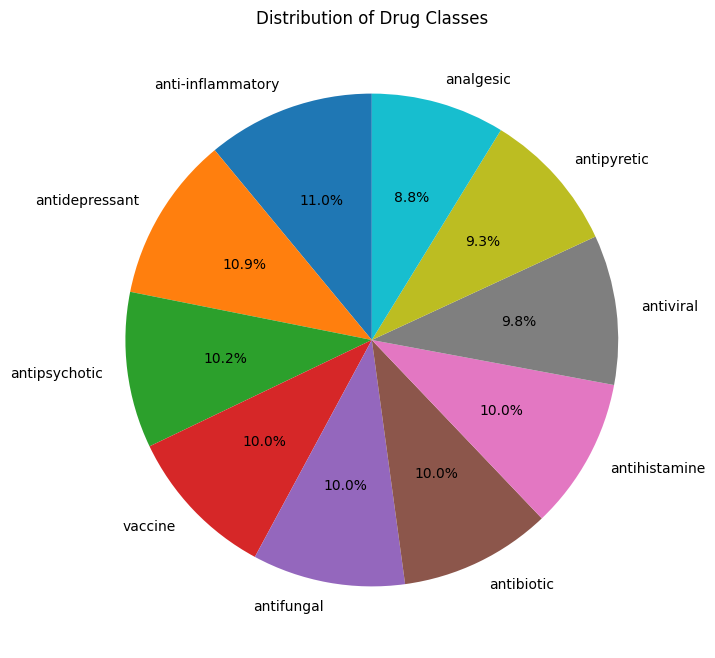

In [32]:
#df['drug_class'].value_counts().plot(
 #   kind='bar',figsize=(8,4),title='Distribution of Drug Classes')

df['drug_class'].value_counts().plot(
    kind='pie', 
    figsize=(8,8),
    autopct='%1.1f%%',       #showing % on pie slices
    startangle=90,           #rotating so first slice starts at the top 
    title='Distribution of Drug Classes')
plt.ylabel('')               #Removes the default y-label for a neat look
plt.show()

##### Anti-Inflammatory drug dominates the drug class by 11% and followed by antidepressant 10.9% ,antipsychotic 10.2% and an equal 10% distribution of vaccine, antifungal, antibiotic and antihistamine.
##### This indicates the focus on pain relief and infection control treatments.

#### Approval trends over time

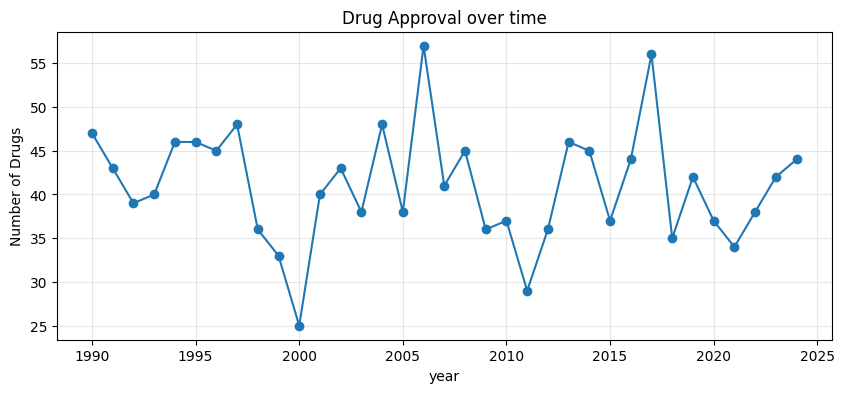

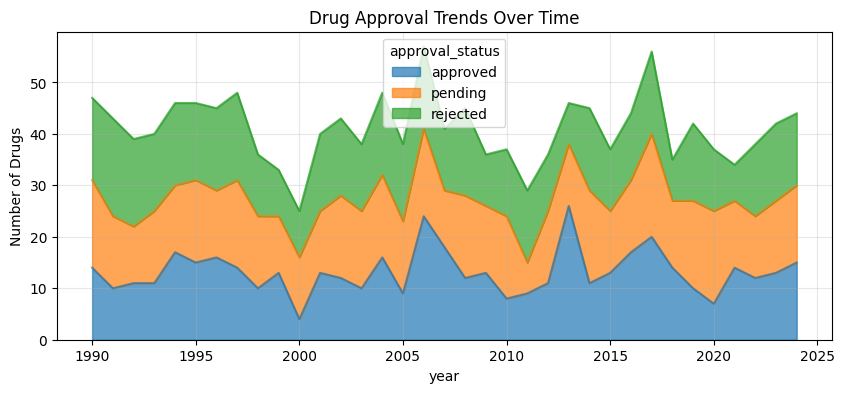

In [38]:
df.groupby('approval_year').size().plot(
    figsize=(10,4),title='Drug Approval over time',marker='o')

plt.xlabel('year')
plt.ylabel('Number of Drugs')
plt.grid(alpha=0.3)
plt.show()

approval_timeline=df.groupby(['approval_year','approval_status']).size().unstack(fill_value=0)
approval_timeline.plot(kind='area',stacked=True,figsize=(10,4),alpha=0.7)
plt.title('Drug Approval Trends Over Time')
plt.xlabel('year')
plt.ylabel('Number of Drugs')
plt.grid(alpha=0.3)
plt.show()

##### The Drug approvals in the recent years are having high pending approvals and high rejected ones this might possibly indicates the tight rules and regulations regarding the approval pattern

#### Drug prices by Manufracturer

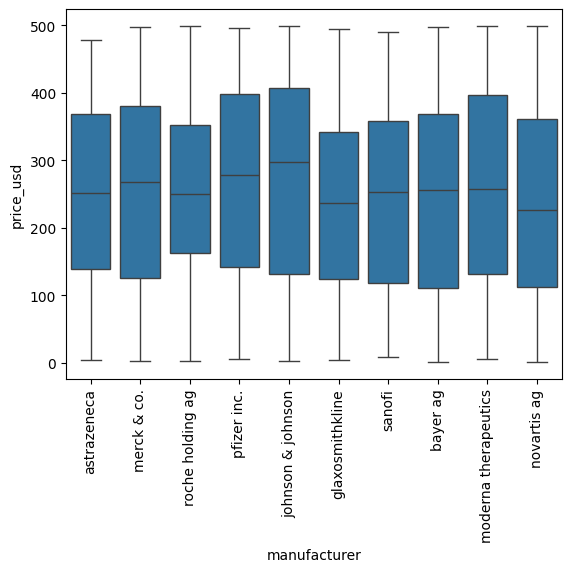

In [43]:
sns.boxplot(data=df,x='manufacturer',y='price_usd')
plt.xticks(rotation=90)
plt.show()

##### From the boxplot we can understand that all the manufacturers have a average price between 200 and 300 and none of the drugs exceeds the price 400 and all are above 100 also. 
##### From this we can understand that the distribution price varies between the manufacturers, but have same averages between 200 and 300, this might be beacuse of some government rules on medicine prices. 

#### Side Effect Severity & Approval Status

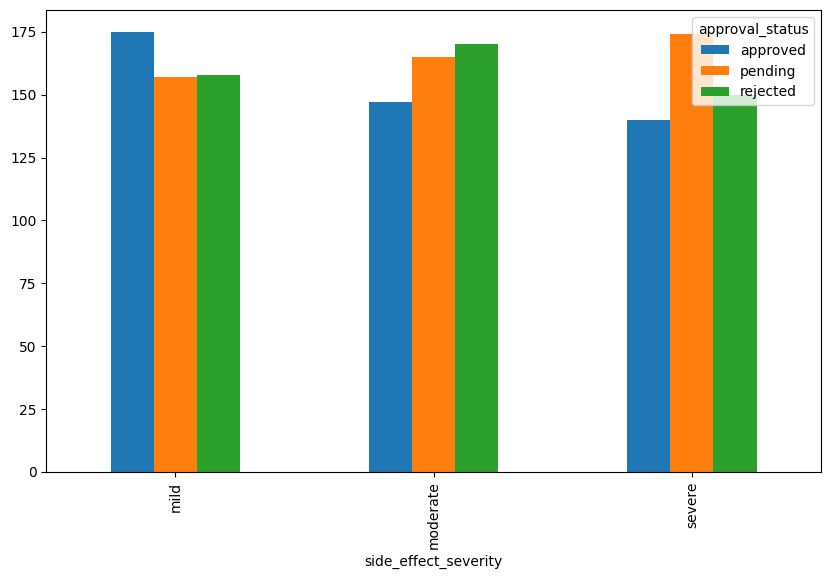

In [71]:
severity_approval=pd.crosstab(
    df['side_effect_severity'],df['approval_status'])
severity_approval.plot(
    kind='bar',
    stacked=False,
    figsize=(10,6))
plt.show()

##### The approval status clearly depends on the side effect severity, the drugs with mild severity is often approved and the approval keeps decreasing in the case of moderate and severe side effects. 

#### Administration Route by Drug Class.

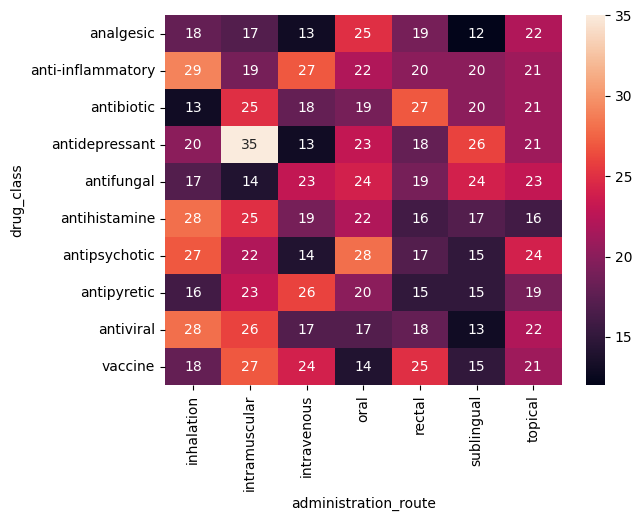

In [52]:
admin_class=pd.crosstab(df['drug_class'],df['administration_route'])
sns.heatmap(admin_class,annot=True,fmt='d')
plt.show()

##### Intramuscular injection is the most commom across the drug classes and but most of the administration route depends on different drug classes. It mainly depends on the diesase and its treatment plans like rectal is an example of eye drops.  

#### Contraindications across Drug Classes.

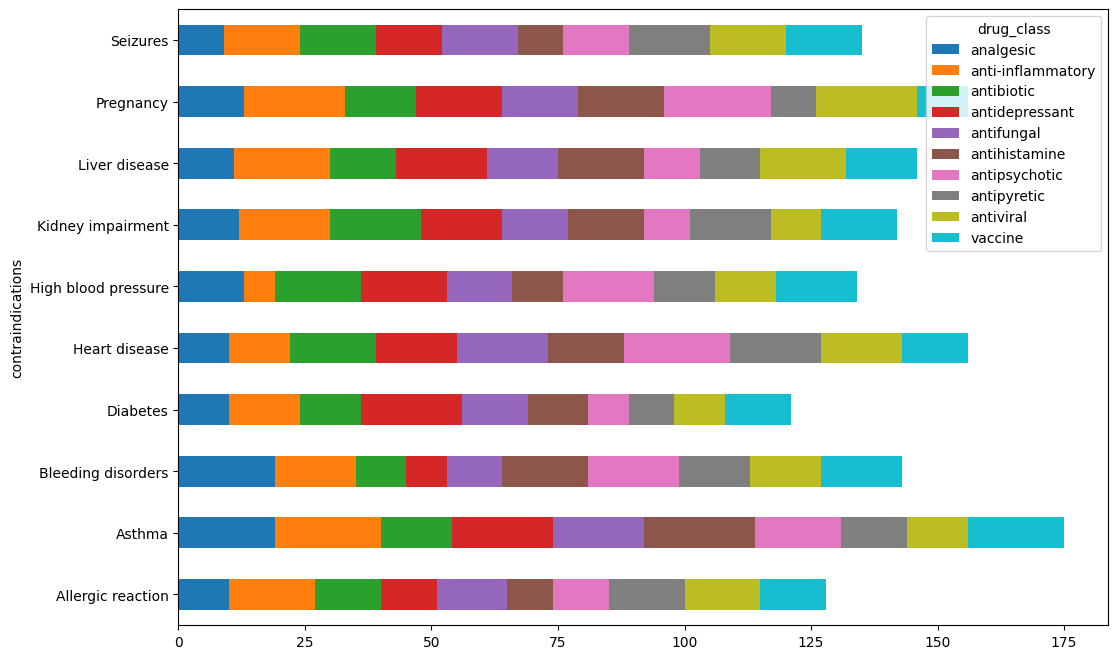

In [61]:
contra_class=pd.crosstab(df['contraindications'],df['drug_class'])
contra_class.plot(kind='barh',stacked=True,figsize=(12,8))
plt.show()

##### Asthma and Pregnancy are the common contraindication, with varying prevalence across drug classes reflecting different safety profiles. 

#### Relationship between drug class, price and side effects

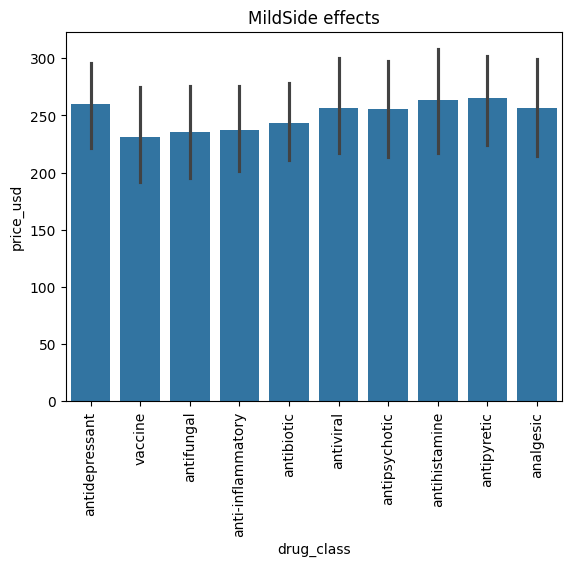

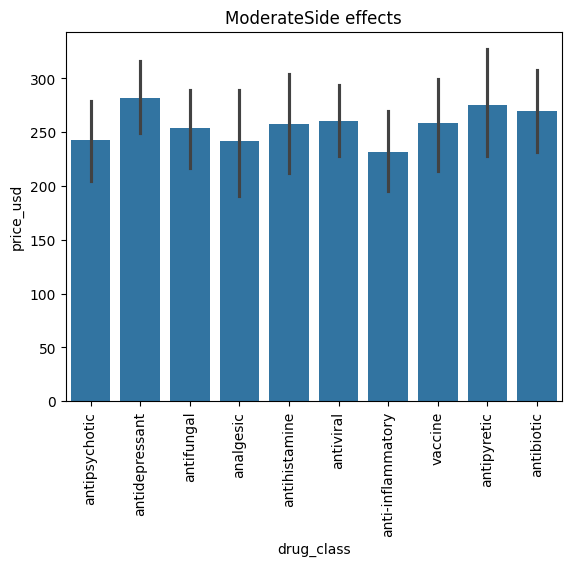

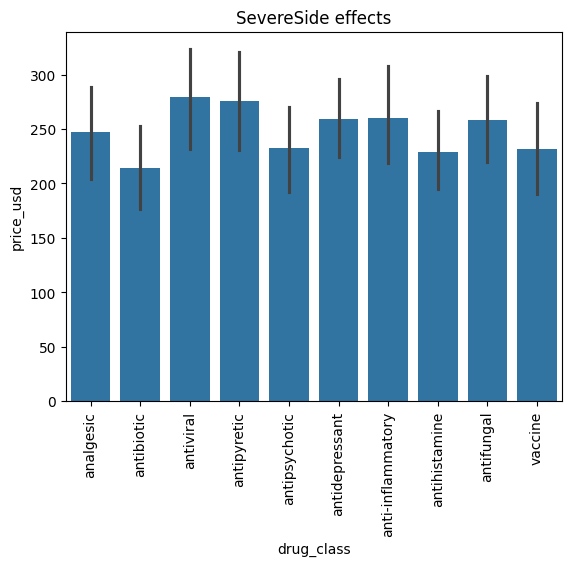

In [65]:
severity_order=['mild','moderate','severe']

for severity in severity_order:
    sns.barplot(
        data=df[df['side_effect_severity']==severity],
            x='drug_class',
            y='price_usd')
    plt.title(f'{severity.capitalize()}Side effects')
    plt.xticks(rotation=90)
    plt.show()

##### Severe side effects drugs show more price varaiation across classes, while mild severity drugs maintain more consistent pricing patterns within classes.

#### Drug indications distributed across manufacturers and their approval success

C:\Users\AnupaSusan\AppData\Local\Temp\ipykernel_3724\3777899313.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indication_counts.values,y=indication_counts.index,palette='coolwarm')


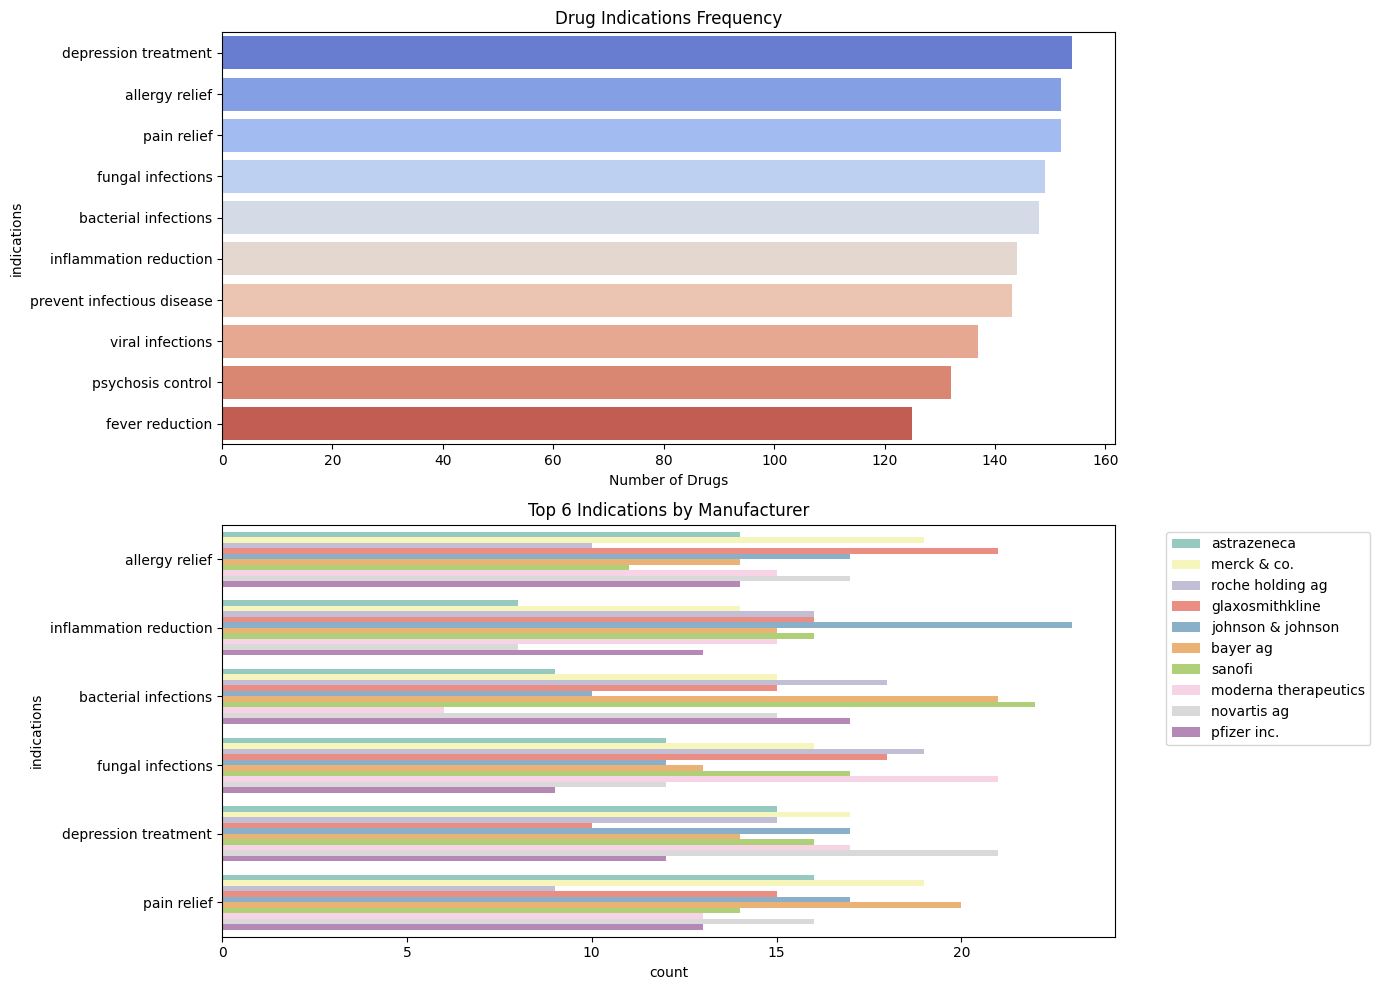

In [69]:
plt.figure(figsize=(14,10))

plt.subplot(2,1,1)
indication_counts=df['indications'].value_counts()
sns.barplot(x=indication_counts.values,y=indication_counts.index,palette='coolwarm')
plt.title('Drug Indications Frequency')
plt.xlabel('Number of Drugs')

plt.subplot(2,1,2)
top_indications=df['indications'].value_counts().head(6).index
filtered_df=df[df['indications'].isin(top_indications)]
sns.countplot(data=filtered_df, y='indications', hue='manufacturer', palette='Set3')
plt.title('Top 6 Indications by Manufacturer')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##### Depression treatment dominates with multiple manufacturers competing, while specialized conditions show manufacturer specific focus, suggesting market segmentation straegies and expertise areas.